# Package overview

This python package is structured around 3 objects : <br>
A receiver : DAS <br>
A path : ray from Pykonal <br>
A source : Radiation pattern <br>
Each can be tuned to create a forward DAS amplitude model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from fct_DAS_sensitivity import *

## DAS sensitivity

Create a DAS channel, It can take : <br>
<u>Orientation </u><br>
* azimuth ($\phi$) : Progress in trigonometric direction origin at the north <br>
==> positif angle rotate toward the west 
* dip ($\theta$) : Progress in antitrigonometric direction origin at the orizontal <br>
==> poitif angle dips the fiber up

<u>Gaugelength effect </u><br>
If thos parameters are given the model uses the gaugelength effect, otherwise, it will uses point strain rate equations. <br>
* Gaugelength : GL <br>
* wavelength : (m) <br>
* velocity : Wave velocity <br>

<u>DAS channel location</u> <br>
* latitude : in ° N <br>
* longitude : in ° W <br>
* depth: in km, positif values are going to the earth <br>

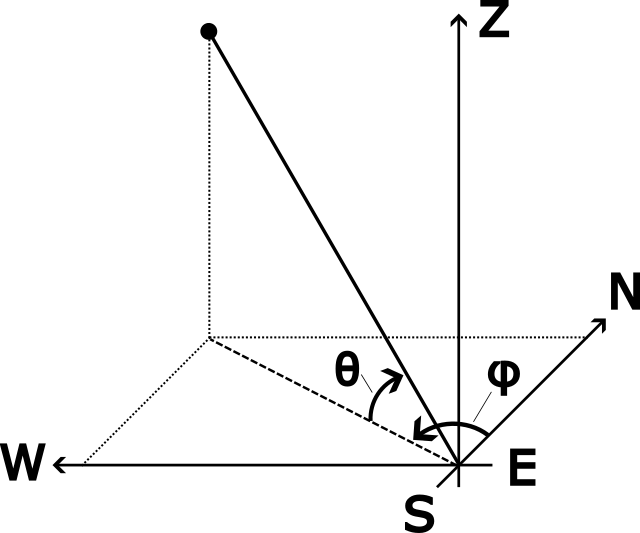

In [14]:
das = DASSensor(
    azimuth=-45,
    dip=45,
    gauge_length=None,
    wavelength=None,
    velocity=None, 
    latitude = None,
    longitude = None,
    depth = None,
)

You can plot the orientation specific response of that channel in a polar plot 

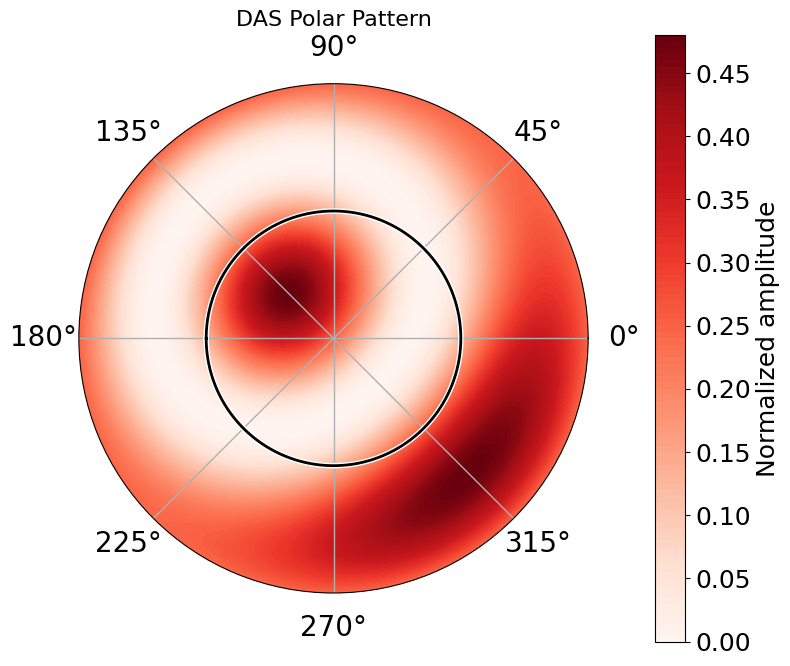

In [15]:
das.plot_polar_pattern('P')

This polar plot can also be viewed in a volume

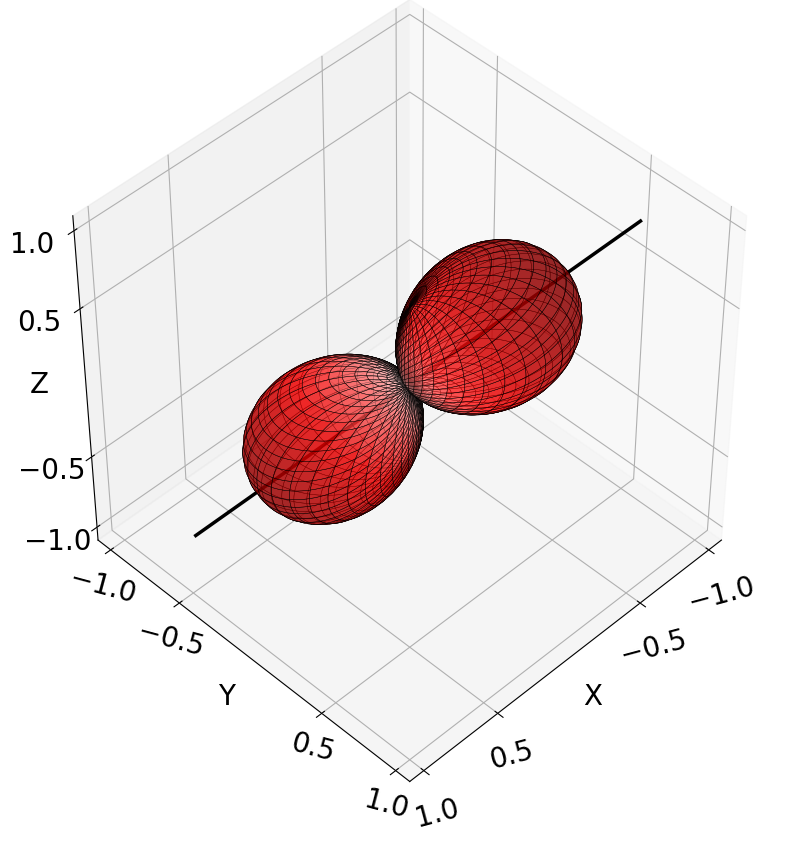

In [16]:
das.plot_3d_fiber_response('P')    

or directly get the sensitivity for a ray coming at e given dip and azimuth <br>
das.sensitivity(phase, azimuth, dip)

In [ ]:
amplitude = das.sensitivity('P', 0, 0)
print(amplitude)

1.5389365549774322e-17


## Run model

#### Seismic source description

mt = IsotropicSource(1) # homogeneous distribution of energy arround the source <br>
mt = MomentTensor(1, 1, -2, 0, 0, 0) # (xx, yy, zz, xy, xz, yz) <br>
mt = SingleForce(1, 1, 0) # (x, y, z) <br>

In [ ]:
# Locate your source in space 
loc = Location(50.85, 4.35, 100)
# Describe the energy inside 
mt = MomentTensor(1, 1, -2, 0, 0, 0) # (xx, yy, zz, xy, xz, yz)
#Create the source object 
source = SeismicSource("My sources", loc, mt)

### For a moment tensor only 

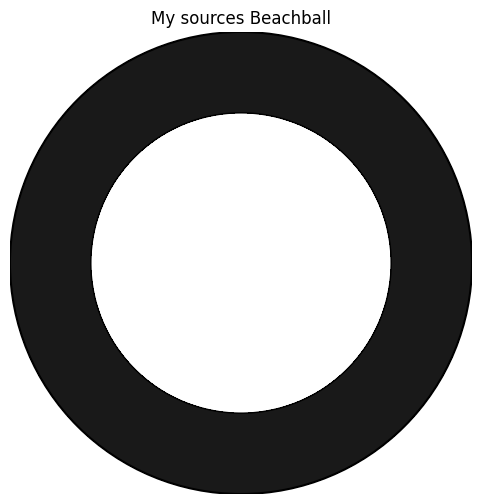

In [ ]:
source.plot_beachball()

### Far all source type see the far field distribution of the energy 

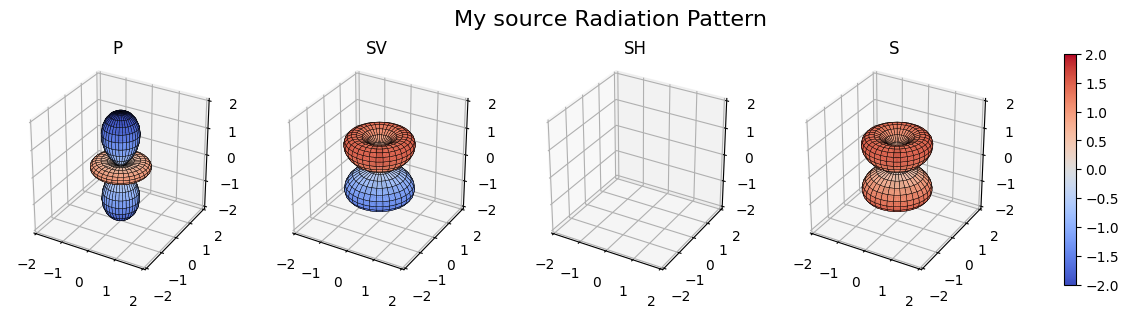

In [ ]:
source.plot_radiation_pattern()